In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip "/content/drive/MyDrive/Codes/cats_and_dogs_filtered.zip"

Archive:  /content/drive/MyDrive/Codes/cats_and_dogs_filtered.zip
   creating: cats_and_dogs_filtered/
  inflating: cats_and_dogs_filtered/.DS_Store  
   creating: cats_and_dogs_filtered/test/
   creating: cats_and_dogs_filtered/train/
   creating: cats_and_dogs_filtered/test/dogs/
   creating: cats_and_dogs_filtered/test/cats/
  inflating: cats_and_dogs_filtered/test/.DS_Store  
   creating: cats_and_dogs_filtered/train/dogs/
   creating: cats_and_dogs_filtered/train/cats/
  inflating: cats_and_dogs_filtered/train/.DS_Store  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2448.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2460.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2461.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2449.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2463.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2462.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2466.jpg  
  inflating: cats_and_dogs_filtered/test

In [4]:
root_dir = r"/content/cats_and_dogs_filtered"

In [5]:
BATCH_SIZE  = 64
EPOCHS = 80
input_img_size = (128,128)
input_shape = (128,128,3)

dropout_rate = 0.4
initial_lr = 1e-3

In [6]:
tf_generator =  tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)


train_ds = tf_generator.flow_from_directory(
    root_dir+"/train",
    target_size=input_img_size,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
val_ds = tf_generator.flow_from_directory(
    root_dir+"/test",
    target_size=input_img_size,
    batch_size=BATCH_SIZE,
    class_mode= 'categorical'
)

Found 2752 images belonging to 2 classes.
Found 248 images belonging to 2 classes.


[0. 1.]


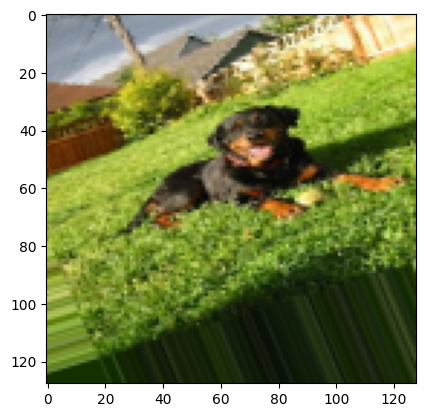

In [7]:
import matplotlib.pyplot as plt
for img,label in train_ds:
    test_img = img
    test_label = label
    break

print(test_label[0])
plt.imshow(test_img[0])

In [8]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Flatten,MaxPooling2D,BatchNormalization,Dropout,Input

model = Sequential([
    Input(shape=input_shape),
    Conv2D(64, (3, 3), activation='relu', padding='same'),  # 1. Conv2D
    Conv2D(64, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(128, (3, 3), activation='relu',padding='same'),
    Conv2D(128, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),


    Conv2D(256, (3, 3), activation='relu',padding='same'),
    Conv2D(256, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),


    Conv2D(512, (3, 3), activation='relu',padding='same'),
    Conv2D(512, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Flatten(),
    Dropout(dropout_rate),

    Dense(256, activation='relu'),
    Dropout(dropout_rate),


    Dense(128, activation='relu'),

    Dense(2, activation='softmax')

])

In [9]:
from tensorflow.keras.optimizers import Adam
model.compile(loss='categorical_crossentropy',
              optimizer = Adam(learning_rate=initial_lr),
              metrics = ['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,111,234 (50.02 MB)

 Trainable params: 13,109,314 (50.01 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [10]:
#  exponential decay:
def exp_decay_lr_scheduler(epoch, lr):
    initial_lr = 1e-2
    end_lr = 1e-5
    decay_epochs = EPOCHS

    # Exponential decay formula
    decay_rate = (end_lr / initial_lr) ** (1 / decay_epochs)
    new_lr = initial_lr * (decay_rate ** epoch)

    print(f"[+] Epoch {epoch:2d} | LR: {new_lr:.6f}")
    return new_lr


tf_lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-2,
    decay_steps=5,  # epochs or batches
    decay_rate=0.5,
    staircase=True  # set False for smooth decay
)

custom_lr_callback = tf.keras.callbacks.LearningRateScheduler(exp_decay_lr_scheduler)

In [11]:
import datetime
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,        # Log histograms every epoch (useful for weights, biases)
    write_graph=True,        # Visualize the model graph
    write_images=False,      # Log weight images (can be heavy)
    update_freq='epoch',     # 'batch' or 'epoch'
    profile_batch=0          # Set >0 to enable performance profiling
)

In [12]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        custom_lr_callback,
        tensorboard_callback
    ]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


[+] Epoch  0 | LR: 0.010000
Epoch 1/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.5066 - loss: 11.1684 - val_accuracy: 0.4597 - val_loss: 0.6953 - learning_rate: 0.0100
[+] Epoch  1 | LR: 0.009173
Epoch 2/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 572ms/step - accuracy: 0.5177 - loss: 0.7101 - val_accuracy: 0.4597 - val_loss: 0.6975 - learning_rate: 0.0092
[+] Epoch  2 | LR: 0.008414
Epoch 3/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 588ms/step - accuracy: 0.5090 - loss: 0.7047 - val_accuracy: 0.4597 - val_loss: 0.6937 - learning_rate: 0.0084
[+] Epoch  3 | LR: 0.007718
Epoch 4/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 588ms/step - accuracy: 0.5068 - loss: 0.7081 - val_accuracy: 0.5403 - val_loss: 0.6929 - learning_rate: 0.0077
[+] Epoch  4 | LR: 0.007079
Epoch 5/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 574ms/step - accuracy: 0.5010 - loss: 0.6949 - val_accuracy: 0.4597 - val_loss: 0.6941 - learning_rate: 0.0071
[+] Epoch  5 | LR: 0.006494
Epoch 6/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 41s 581ms/step - accuracy: 0.50

In [13]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 345ms/step - accuracy: 0.5714 - loss: 0.6607
Validation Loss: 0.6645
Validation Accuracy: 0.5847


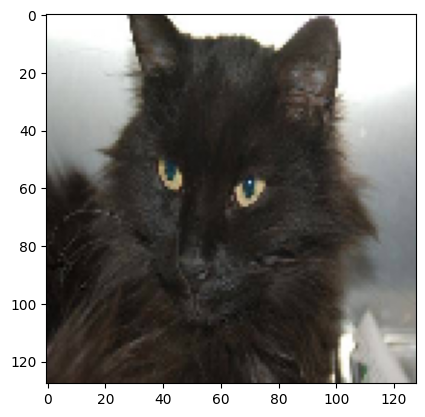

In [15]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = r"/content/cats_and_dogs_filtered/test/cats/cat.2427.jpg"

img = image.load_img(img_path, target_size=input_img_size)
img_array = image.img_to_array(img)  # shape: (_, _, 3)
img_array = img_array / 255.0        # normalize

img_array = np.expand_dims(img_array, axis=0)  # shape: (1, _, _, 3)
plt.imshow(img_array[0])  # Display the image

In [26]:
train_ds.class_indices.keys()

dict_keys(['cats', 'dogs'])

In [28]:
# class_names = train_ds.class_names

# Convert to dict
# class_indices = {name: idx for idx, name in enumerate(class_names)}
class_indices = train_ds.class_indices
print("Class names found:", class_indices)

Class names found: {'cats': 0, 'dogs': 1}


In [29]:
model.predict(img_array)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


np.float32(0.63105255)

In [30]:
prediction = model.predict(img_array)[0][0]
class_name = "dogs" if prediction > 0.5 else "cats"

print(f"Predicted class: {class_name} with confidence {prediction:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted class: dogs with confidence 0.63


### Model Saving

In [31]:
# import os
# from dotenv import load_dotenv
# load_dotenv()

# ML_Summer_School_ID = os.getenv('ML_Summer_School_ID')
# print("Your Sudent ID is: " + ML_Summer_School_ID)

In [32]:
model.save(f'./binary_classification/ML004_Thant_Htet_Oo_model.h5')

In [33]:
import json
# Save class names to a text file
with open(f'./binary_classification/ML004_Thant_Htet_Oo_class_indices.json', 'w') as f:
    # class_names =class_names

    # Convert to dict
    # class_indices = {name: idx for idx, name in enumerate(class_names)}

    json.dump(class_indices, f)
